# Исследование сортировки
**(20 баллов)**<br/>
**4 вариант**</br>
Изучите сортировку Шелла и реализуйте ее в виде функции shell_sort(some_list). Функция принимает список и сортирует его по возрастанию.
1.	(2 балла) Выпишите результаты всех итераций сортировки Шелла с шагами 7, 5, 3 и 1 на списке [16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]. Сколько сравнений было выполнено? 
2.	(2 балла) Выпишите результаты всех итераций сортировки Шелла с шагами 8, 4, 2 и 1 на списке [16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]. Сколько сравнений было выполнено?
3.	(2 балла) Выпишите результаты всех итераций сортировки Шелла с шагами 5, 2 и 1 на списке [7, 3, 9, 4, 2, 5, 6, 1, 8]. Сколько сравнений было выполнено?
4.	(2 балла) Выпишите результаты всех итераций сортировки Шелла с шагами 5, 2 и 1 на списке [3, 5, 2, 9, 8, 1, 6, 4, 7]. Сколько сравнений было выполнено?
5.	(4 балла) Приведите анализ асимптотической сложности алгоритма сортировки. Напишите значения его временной и пространственной сложностей.
6.	(8 баллов) Проведите вычислительные эксперименты и нарисуйте графики, показывающие зависимость времени выполнения от размера входных данных n. Возьмите n равное: 100, 500, 1000, 2000, 4000, 6000, 8000, 10000. 
Реализуйте функции для генерации следующих вариантов входных данных: 

a.	список случайных чисел;<br/>
b.	отсортированный в обратную сторону список;</br>
c.	почти отсортированный список (один элемент в середине списка находится не на своем месте);<br/> 
d.	половина данных равна 0, половина оставшихся 1, половина оставшихся 2 и т.д.;<br/>
e.	первые 5% списка содержат случайные значения, а оставшиеся 95% упорядочены;<br/>
f.	все элементы находятся в пределах 10 позиций от окончательного места в массиве.<br/>

График зависимостей должен быть представлен для каждого варианта входных данных.

На каком из вариантов сортировка работает быстрее всего? На каком из вариантов – медленнее? Как вы можете это объяснить?  


In [ ]:
def shell_sort(a):
    n = len(a)
    gap = n // 2
    while gap > 0:
        # gapped insertion sort
        for i in range(gap, n):
            temp = a[i]
            j = i
            while j >= gap and a[j - gap] > temp:
                a[j] = a[j - gap]
                j -= gap
            a[j] = temp
        gap //= 2
    return a


1.	(2 балла) Выпишите результаты всех итераций сортировки Шелла с шагами 7, 5, 3 и 1 на списке [16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]. Сколько сравнений было выполнено? 

In [7]:
def shell_sort_trace(a, gaps):
    a = a[:]
    comparisons = 0
    snapshots = []

    n = len(a)
    for gap in gaps:
        for i in range(gap, n):
            temp = a[i]
            j = i
            while j >= gap:
                comparisons += 1 # подсчет сравнений
                if a[j - gap] > temp:
                    a[j] = a[j - gap]
                    j -= gap
                else:
                    break
            a[j] = temp
        snapshots.append((gap, a[:]))
    return snapshots, comparisons

data = [16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
gaps = [7, 5, 3, 1]

snaps, comps = shell_sort_trace(data, gaps)
for gap, arr in snaps:
    print(f"gap={gap}: {arr}")
print("comparisons =", comps)

gap=7: [2, 1, 7, 6, 5, 4, 3, 9, 8, 14, 13, 12, 11, 10, 16, 15]
gap=5: [2, 1, 7, 6, 5, 4, 3, 9, 8, 14, 13, 12, 11, 10, 16, 15]
gap=3: [2, 1, 4, 3, 5, 7, 6, 9, 8, 11, 10, 12, 14, 13, 16, 15]
gap=1: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
comparisons = 59


2.	(2 балла) Выпишите результаты всех итераций сортировки Шелла с шагами 8, 4, 2 и 1 на списке [16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]. Сколько сравнений было выполнено?

In [6]:
# используем тот же 'shell_sort_trace()'

data = [16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
gaps = [8, 4, 2, 1]

snaps, comps = shell_sort_trace(data, gaps)
for gap, arr in snaps:
    print(f"gap={gap}: {arr}")
print("comparisons =", comps)


gap=8: [8, 7, 6, 5, 4, 3, 2, 1, 16, 15, 14, 13, 12, 11, 10, 9]
gap=4: [4, 3, 2, 1, 8, 7, 6, 5, 12, 11, 10, 9, 16, 15, 14, 13]
gap=2: [2, 1, 4, 3, 6, 5, 8, 7, 10, 9, 12, 11, 14, 13, 16, 15]
gap=1: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
comparisons = 66


3.	(2 балла) Выпишите результаты всех итераций сортировки Шелла с шагами 5, 2 и 1 на списке [7, 3, 9, 4, 2, 5, 6, 1, 8]. Сколько сравнений было выполнено?

In [5]:
# используем тот же 'shell_sort_trace()'

data = [7, 3, 9, 4, 2, 5, 6, 1, 8]
gaps = [5, 2, 1]

snaps, comps = shell_sort_trace(data, gaps)
for gap, arr in snaps:
    print(f"gap={gap}: {arr}")
print("comparisons =", comps)


gap=5: [5, 3, 1, 4, 2, 7, 6, 9, 8]
gap=2: [1, 3, 2, 4, 5, 7, 6, 9, 8]
gap=1: [1, 2, 3, 4, 5, 6, 7, 8, 9]
comparisons = 23


4.	(2 балла) Выпишите результаты всех итераций сортировки Шелла с шагами 5, 2 и 1 на списке [3, 5, 2, 9, 8, 1, 6, 4, 7]. Сколько сравнений было выполнено?

In [ ]:
# используем тот же 'shell_sort_trace()'

data = [3, 5, 2, 9, 8, 1, 6, 4, 7]
gaps = [5, 2, 1]

snaps, comps = shell_sort_trace(data, gaps)
for gap, arr in snaps:
    print(f"gap={gap}: {arr}")
print("comparisons =", comps)


gap=5: [1, 5, 2, 7, 8, 3, 6, 4, 9]
gap=2: [1, 3, 2, 4, 6, 5, 8, 7, 9]
gap=1: [1, 2, 3, 4, 5, 6, 7, 8, 9]
comparisons = 26


5.	(4 балла) Приведите анализ асимптотической сложности алгоритма сортировки. Напишите значения его временной и пространственной сложностей.

In [ ]:
"""
Временная сложнсоть Shell Sort зависит от последовательности шагов
Для часто используемой последовательности n/2, n/4, ..., 1 обычно указывают:
 - худший случай: O(n^2)
 - память: O(1) (in-place)

Т.к. использует лишь несколько временных переменных, по типу 'temp','gap' и индексов
"""

6.	(8 баллов) Проведите вычислительные эксперименты и нарисуйте графики, показывающие зависимость времени выполнения от размера входных данных n. Возьмите n равное: 100, 500, 1000, 2000, 4000, 6000, 8000, 10000. 
Реализуйте функции для генерации следующих вариантов входных данных: 

a.	список случайных чисел;<br/>
b.	отсортированный в обратную сторону список;</br>
c.	почти отсортированный список (один элемент в середине списка находится не на своем месте);<br/> 
d.	половина данных равна 0, половина оставшихся 1, половина оставшихся 2 и т.д.;<br/>
e.	первые 5% списка содержат случайные значения, а оставшиеся 95% упорядочены;<br/>
f.	все элементы находятся в пределах 10 позиций от окончательного места в массиве.<br/>

График зависимостей должен быть представлен для каждого варианта входных данных.

На каком из вариантов сортировка работает быстрее всего? На каком из вариантов – медленнее? Как вы можете это объяснить?  

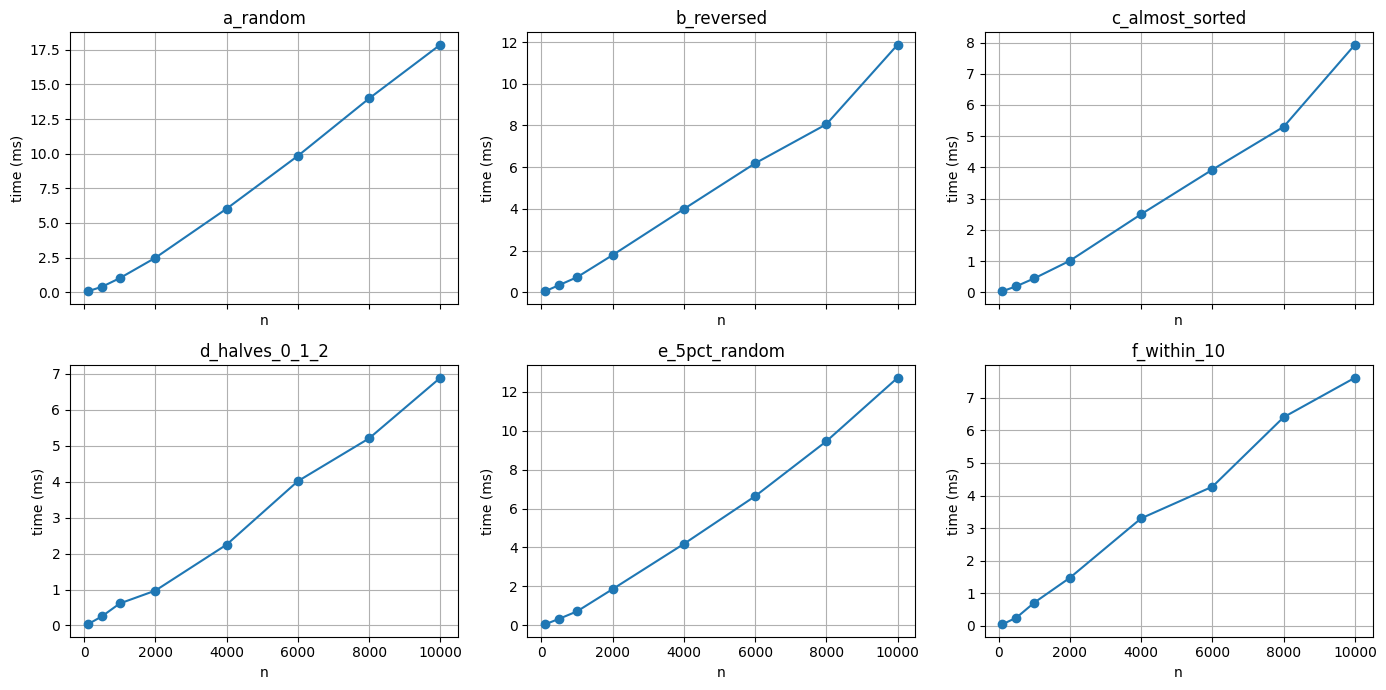

fastest: d_halves_0_1_2 avg_ms: 2.5286824988143053
slowest: a_random avg_ms: 6.461858333689937
a_random             | 6.461858333689937
b_reversed           | 4.1266758332009585
c_almost_sorted      | 2.669613334486106
d_halves_0_1_2       | 2.5286824988143053
e_5pct_random        | 4.491869166182975
f_within_10          | 3.0092358341789804


In [ ]:
import random
import time
import statistics
import matplotlib.pyplot as plt

# Ф-ция 'shell_sort()' в начале

def gen_random(n):
    return [random.randrange(0, n) for _ in range(n)]

def gen_reversed(n):
    return list(range(n, 0, -1))

def gen_almost_sorted_one_mid_wrong(n):
    a = list(range(n))
    if n >= 2:
        m = n // 2
        a[m], a[m + 1] = a[m + 1], a[m]
    return a

def gen_halves_0_1_2(n):
    out = []
    remaining = n
    value = 0

    while remaining > 0:
        k = 1 if remaining == 1 else remaining // 2
        out.extend([value] * k)
        remaining -= k
        value += 1

    return out

def gen_5pct_random_rest_sorted(n):
    a = list(range(n))
    m = int(0.05 * n)
    for i in range(m):
        a[i] = random.randrange(0, n)
    prefix = a[:m]
    random.shuffle(prefix)
    a[:m] = prefix
    return a

def gen_within_10_positions(n):
    a = list(range(n))
    block = 11
    for start in range(0, n, block):
        end = min(n, start + block)
        b = a[start:end]
        rnd.shuffle(b)
        a[start:end] = b
    return a

def time_shellsort(data, repeats=3):
    ts = []
    for _ in range(repeats):
        arr = data.copy()
        t0 = time.perf_counter()
        shell_sort(arr)
        ts.append(time.perf_counter() - t0)
    return statistics.mean(ts) * 1000  # ms

variants = {
    "a_random": gen_random,
    "b_reversed": gen_reversed,
    "c_almost_sorted": gen_almost_sorted_one_mid_wrong,
    "d_halves_0_1_2": gen_halves_0_1_2,
    "e_5pct_random": gen_5pct_random_rest_sorted,
    "f_within_10": gen_within_10_positions,
}

ns = [100, 500, 1000, 2000, 4000, 6000, 8000, 10000]

results = {name: [] for name in variants}
for n in ns:
    repeats = 5 if n <= 2000 else 3
    for name, gen in variants.items():
        results[name].append(time_shellsort(gen(n), repeats=repeats))

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
axes = axes.flatten()

for ax, (name, times) in zip(axes, results.items()):
    ax.plot(ns, times, marker="o")
    ax.set_title(name)
    ax.set_xlabel("n")
    ax.set_ylabel("time (ms)")
    ax.grid(True)

plt.tight_layout()
plt.show()

avg = {name: sum(times) / len(times) for name, times in results.items()}
fastest = min(avg, key=avg.get)
slowest = max(avg, key=avg.get)
print("fastest:", fastest, "avg_ms:", avg[fastest])
print("slowest:", slowest, "avg_ms:", avg[slowest])

for name, times in results.items():
    avg_ms = sum(times) / len(times)
    print(f"{name:<20} | {avg_ms}")


In [ ]:
"""
Сортировка быстрее всего работает на варианте d_halves_0_1, а 
медленнее всего — на варианте a_random.

Полностью случайные данные обычно дают ожидаемую нагрузку для 
сравнительных сортировок: мало упорядоченных участков, много 
перестановок/сравнений, поэтому время максимальное.

Почти отсортированные данные и данные с большим количеством 
одинаковых элементов часто сортируются быстрее: 
либо из‑за меньшего числа перемещений, 
либо потому что алгоритм лучше использует повторяющиеся 
ключи/естественные упорядоченные блоки.
"""